In [82]:
import tensorflow as tf
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Sequential
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import seaborn as sns
from pathlib import Path




In [14]:
train_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/train'
val_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/val'
test_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/test'

In [75]:
count_normal = len(os.listdir(os.path.join(train_dir, 'normal')))
count_pneumonia = len(os.listdir(os.path.join(train_dir, 'pneumonia')))
count_tuberulosis = len(os.listdir(os.path.join(train_dir, 'tuberculosis')))

In [76]:
print(f"Number of normal images in training set: {count_normal}")
print(f"Number of pneumonia images in training set: {count_pneumonia}")
print(f"Number of tuberulosis images in training set: {count_tuberulosis}")

Number of normal images in training set: 7263
Number of pneumonia images in training set: 4674
Number of tuberulosis images in training set: 8513


In [24]:
image_height = 224
image_width = 224
batch_size = 10


In [60]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    color_mode = 'grayscale',
    image_size = (image_height, image_width),
    batch_size = batch_size
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    color_mode = 'grayscale',
    image_size = (image_height, image_width),
    batch_size = batch_size
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    color_mode = 'grayscale',
    image_size = (image_height, image_width),
    batch_size = batch_size
)

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.


In [26]:
train_ds.class_names

['normal', 'pneumonia', 'tuberculosis']

2025-11-14 09:46:02.747003: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


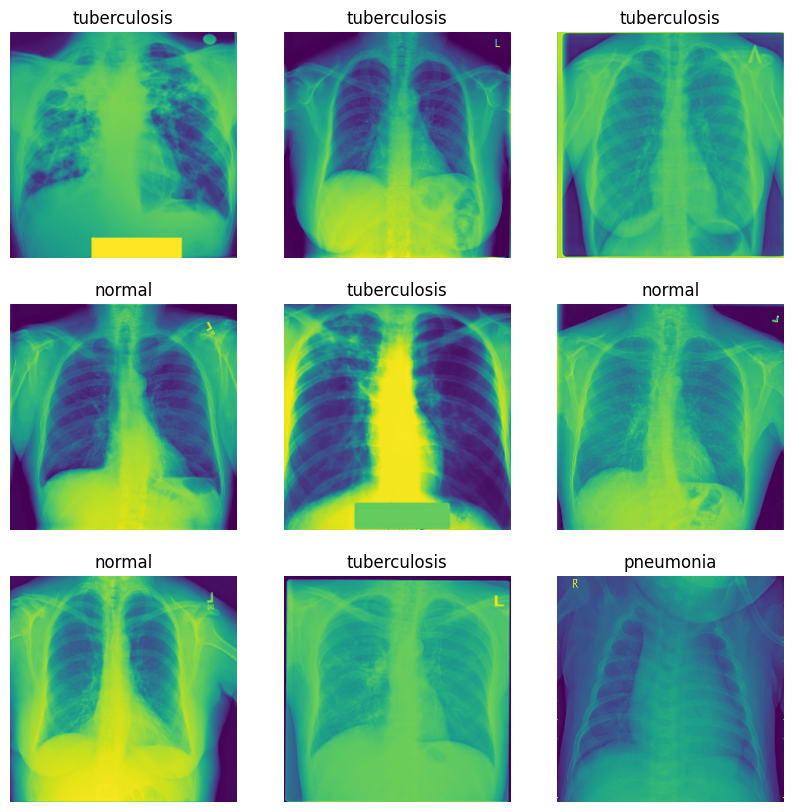

In [27]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis('off')

In [67]:
autotune = tf.data. experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = autotune)
val_ds = val_ds.cache().prefetch(buffer_size = autotune)
test_ds = test_ds.cache().prefetch(buffer_size = autotune)

In [68]:
model = tf.keras.Sequential([
   tf.keras.layers.Rescaling(1./255), 
    tf.keras.layers.Conv2D(32, 3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(3, activation = 'softmax')
])

In [69]:
model.compile(optimizer = 'Adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics = ['accuracy'])

In [70]:
epochs = 10

In [71]:
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = epochs
)

Epoch 1/10


/opt/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


2045/2045 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.6969 - loss: 0.6375 - val_accuracy: 0.6425 - val_loss: 0.7681
Epoch 2/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6938 - loss: 0.8815 - val_accuracy: 0.6768 - val_loss: 2.4689
Epoch 3/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6906 - loss: 2.3028 - val_accuracy: 0.6969 - val_loss: 3.3925
Epoch 4/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6794 - loss: 8.7077 - val_accuracy: 0.6638 - val_loss: 8.0015
Epoch 5/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6780 - loss: 36.3389 - val_accuracy: 0.6342 - val_loss: 30.1848
Epoch 6/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6834 - loss: 70.7734 - val_accuracy: 0.7234 - val_loss: 77.2814
Epoch 7/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6860 - loss: 168.8051 - val_accuracy: 0.7028 - val_loss: 298.7180
Epoch 8/10
2045/2045 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6841 - lo

In [72]:
model.evaluate(test_ds)

257/257 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6952 - loss: 2057.8301


[2057.830078125, 0.6952121257781982]